# Projet Économétrie Qualitative — Modélisation des notations Yuka
## Parties 1 : Présentation · Statistiques descriptives · Analyse exploratoire

**Groupe :** Palla Gueye · Havar Baskara · Mouhammad Gaye  
**Master 1 BIDABI — Université Sorbonne Paris Nord**  
**Cours : Économétrie des données qualitatives**


## 0. Imports et configuration

On importe les librairies nécessaires et on configure les chemins dynamiques pour que le notebook fonctionne depuis n'importe quel emplacement dans le repo.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, chi2_contingency

import warnings
warnings.filterwarnings("ignore")

# Chemins dynamiques
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if not os.path.exists(os.path.join(BASE_DIR, "data")):
    BASE_DIR = os.getcwd()
FIGURES_DIR = os.path.join(BASE_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# Style graphique
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120

print(f"✅ Imports OK")
print(f"📁 BASE_DIR    : {BASE_DIR}")
print(f"📁 FIGURES_DIR : {FIGURES_DIR}")

✅ Imports OK
📁 BASE_DIR    : c:\Users\gayem\Desktop\jeu_donnees_YUKA
📁 FIGURES_DIR : c:\Users\gayem\Desktop\jeu_donnees_YUKA\figures


---
## Partie 1 — Présentation des données

### Objectif
Avant toute analyse, il est indispensable de comprendre la structure du dataset : nombre d'observations, nature des variables, présence de valeurs manquantes, et distribution de la variable à expliquer.

### 1.1 Chargement des données

In [2]:
df = pd.read_csv(os.path.join(BASE_DIR, "data", "jeu_donnees_yuka.csv"),
                 sep=None, engine="python")
df = df.drop(columns=["id_produit"])

print(f"Nombre d'observations : {df.shape[0]}")
print(f"Nombre de variables   : {df.shape[1]}")
df.head()

Nombre d'observations : 1000
Nombre de variables   : 11


,calories_100g,sucres_100g,graisses_saturees_100g,sel_100g,fibres_100g,proteines_100g,nb_additifs,bio,ultra_transforme,score_yuka_ordonne,classe_yuka
0,229.8,10.3,3.7,1.22,2.7,0.0,4,1,1,1,Mauvais
1,282.5,23.6,6.0,0.87,1.2,1.9,0,0,0,1,Mauvais
2,446.7,32.8,3.3,1.03,7.0,12.5,2,0,0,1,Mauvais
3,121.8,20.8,6.0,0.07,5.1,2.0,2,1,1,2,Médiocre
4,257.0,16.6,3.3,1.64,1.4,10.6,0,0,0,2,Médiocre


### 1.2 Types des variables

In [3]:
print("Types des variables :")
print(df.dtypes)

Types des variables :
calories_100g             float64
sucres_100g               float64
graisses_saturees_100g    float64
sel_100g                  float64
fibres_100g               float64
proteines_100g            float64
nb_additifs                 int64
bio                         int64
ultra_transforme            int64
score_yuka_ordonne          int64
classe_yuka                object
dtype: object


**Interprétation :**

- `score_yuka_ordonne` est notre **variable dépendante ordonnée** (1=Mauvais, 2=Médiocre, 3=Bon, 4=Excellent). Son caractère ordonné justifie l'usage d'un **modèle Logit Ordonné** plutôt qu'une régression linéaire ou un logit binaire.
- Les **variables quantitatives** (calories, sucres, etc.) mesurent la composition nutritionnelle des produits.
- Les **variables qualitatives binaires** (bio, ultra_transforme) capturent des caractéristiques structurelles du produit.

### 1.3 Valeurs manquantes

In [4]:
print("Valeurs manquantes par variable :")
display(df.isnull().sum().to_frame("Nulls"))
print("\n→ Aucune valeur manquante : le dataset est complet, aucun traitement d'imputation n'est nécessaire.")

Valeurs manquantes par variable :


,Nulls
calories_100g,0
sucres_100g,0
graisses_saturees_100g,0
sel_100g,0
fibres_100g,0
proteines_100g,0
nb_additifs,0
bio,0
ultra_transforme,0
score_yuka_ordonne,0



→ Aucune valeur manquante : le dataset est complet, aucun traitement d'imputation n'est nécessaire.


### 1.4 Distribution de la variable dépendante

In [5]:
dist_y = df["score_yuka_ordonne"].value_counts().sort_index()
labels = {1: "Mauvais", 2: "Médiocre", 3: "Bon", 4: "Excellent"}

print("Distribution de score_yuka_ordonne :")
for k, v in dist_y.items():
    print(f"  {k} — {labels[k]:10s} : {v:4d} produits ({100*v/len(df):.1f}%)")

Distribution de score_yuka_ordonne :
  1 — Mauvais    :  368 produits (36.8%)
  2 — Médiocre   :  269 produits (26.9%)
  3 — Bon        :  230 produits (23.0%)
  4 — Excellent  :  133 produits (13.3%)


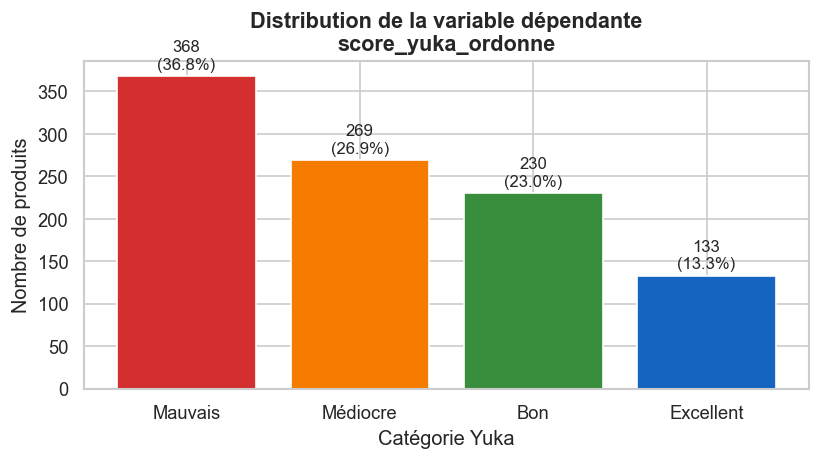

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#d32f2f", "#f57c00", "#388e3c", "#1565c0"]
bars = ax.bar([labels[k] for k in dist_y.index], dist_y.values, color=colors, edgecolor="white")
for bar, val in zip(bars, dist_y.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{val}\n({100*val/len(df):.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_title("Distribution de la variable dépendante\nscore_yuka_ordonne", fontsize=13, fontweight="bold")
ax.set_ylabel("Nombre de produits")
ax.set_xlabel("Catégorie Yuka")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig1_distribution_Y.png"))
plt.show()

**Interprétation :**

La majorité des produits (36.8%) sont classés **Mauvais**, ce qui reflète la réalité de l'offre alimentaire industrielle. Seulement 13.3% atteignent le score **Excellent**. Cette distribution déséquilibrée est un fait stylisé important à mentionner avant l'estimation du modèle.

---
## Partie 2 — Statistiques descriptives

In [7]:
vars_quanti = ["calories_100g", "sucres_100g", "graisses_saturees_100g",
               "sel_100g", "fibres_100g", "proteines_100g", "nb_additifs"]
vars_quali  = ["bio", "ultra_transforme"]

### 2.1 Variables quantitatives — Statistiques descriptives

In [8]:
stats_desc = df[vars_quanti].agg(["mean", "std", "min",
                                   lambda x: x.quantile(0.25),
                                   "median",
                                   lambda x: x.quantile(0.75),
                                   "max"])
stats_desc.index = ["Moyenne", "Écart-type", "Min", "Q1", "Médiane", "Q3", "Max"]
display(stats_desc.round(3))

,calories_100g,sucres_100g,graisses_saturees_100g,sel_100g,fibres_100g,proteines_100g,nb_additifs
Moyenne,243.176,12.686,4.070,0.816,3.023,7.247,1.652
Écart-type,132.696,9.112,2.711,0.557,2.113,4.720,2.065
Min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Q1,145.275,5.300,2.075,0.370,1.400,3.600,0.000
Médiane,237.350,12.150,3.900,0.775,2.800,7.200,1.000
Q3,333.550,19.300,6.000,1.210,4.400,10.500,2.000
Max,634.600,41.500,13.500,2.530,10.300,22.800,12.000


**Interprétation économique :**

- **Sucres :** l'OMS recommande moins de 25g/jour — la moyenne observée est déjà préoccupante.
- **Sel :** niveau cohérent avec une consommation industrielle souvent excessive en sodium.
- **Graisses saturées :** associées aux risques cardiovasculaires.
- **Fibres :** bien en dessous des apports journaliers recommandés (25g/jour).
- **Additifs :** indicateur clé de la transformation industrielle.

→ Les variables *néfastes* (sucres, sel, graisses, additifs) devraient avoir un **effet négatif** sur le score Yuka, et les variables *bénéfiques* (fibres, protéines) un **effet positif**.

### 2.2 Histogrammes des variables quantitatives

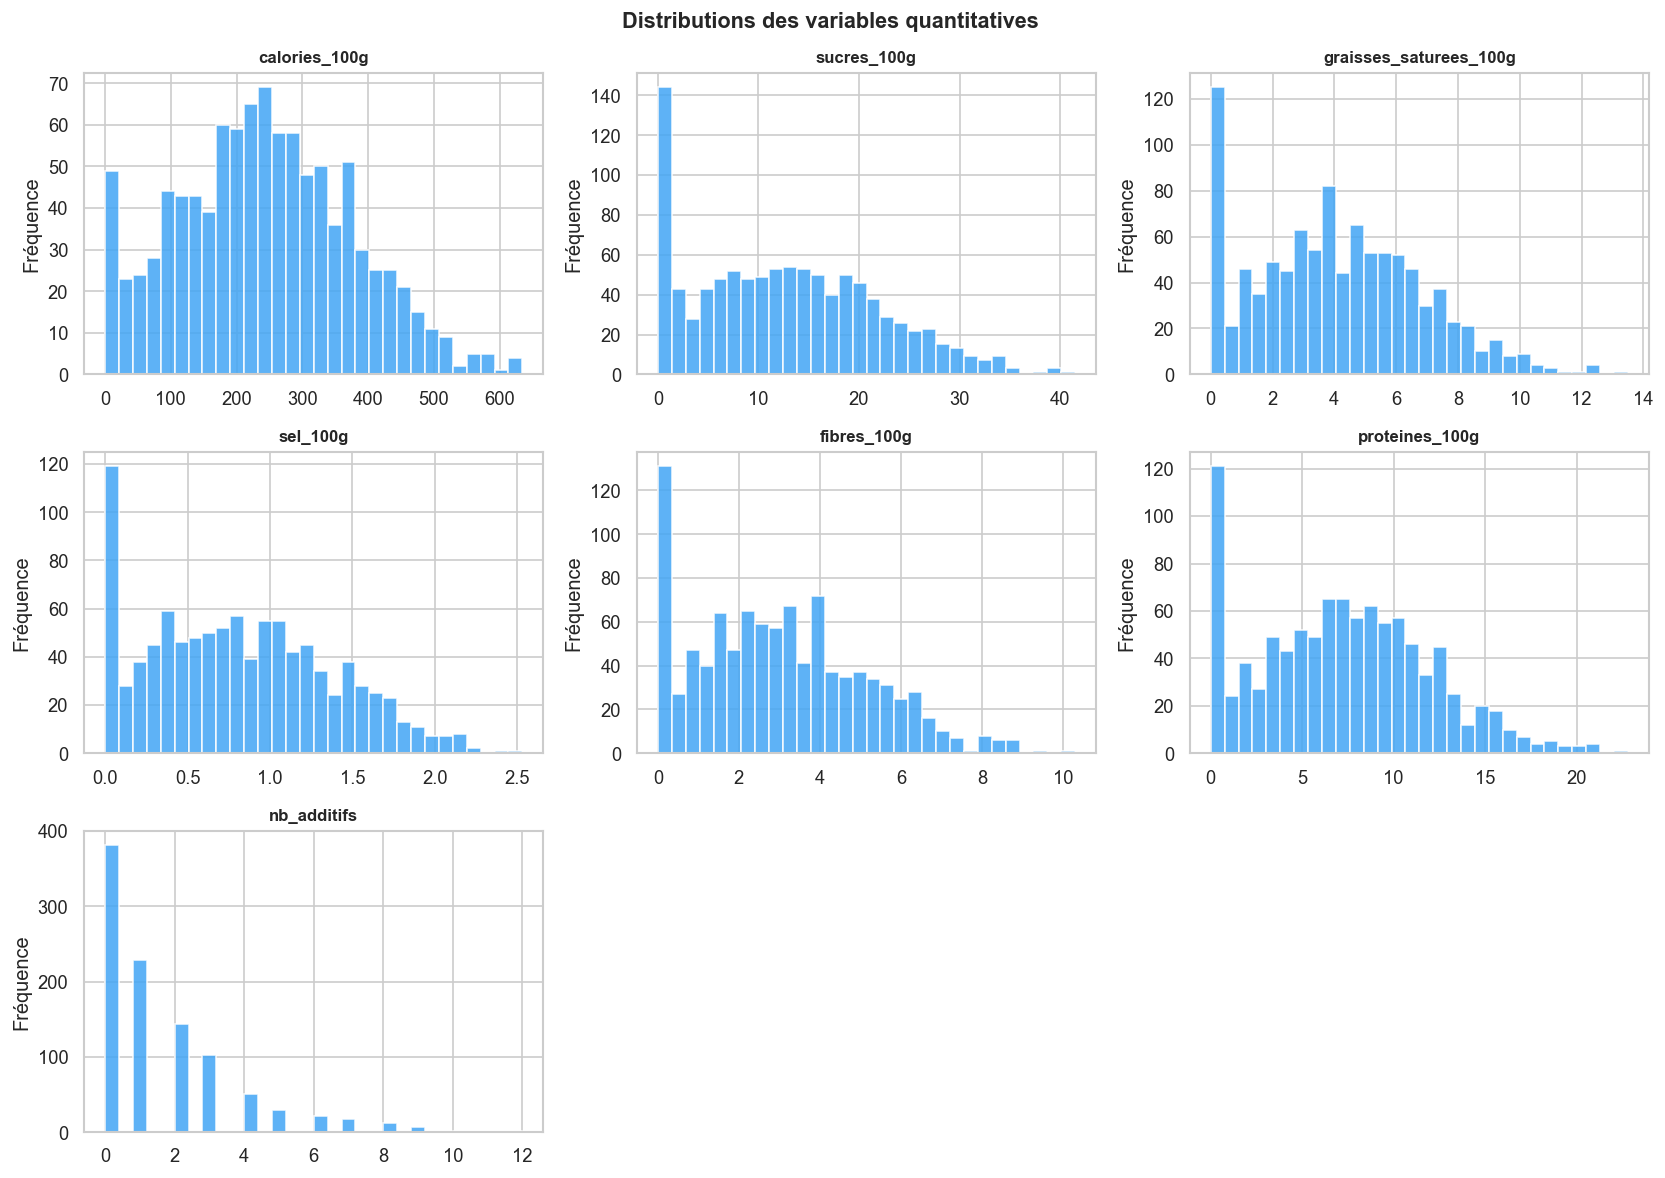

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, var in enumerate(vars_quanti):
    axes[i].hist(df[var], bins=30, color="#42a5f5", edgecolor="white", alpha=0.85)
    axes[i].set_title(var, fontsize=10, fontweight="bold")
    axes[i].set_ylabel("Fréquence")
for j in range(len(vars_quanti), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Distributions des variables quantitatives", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig2_histogrammes_quanti.png"))
plt.show()

### 2.3 Variables qualitatives — Statistiques descriptives

In [10]:
for var in vars_quali:
    freq = df[var].value_counts()
    print(f"{var} :")
    print(f"  0 (Non) : {freq.get(0,0):4d} produits ({100*freq.get(0,0)/len(df):.1f}%)")
    print(f"  1 (Oui) : {freq.get(1,0):4d} produits ({100*freq.get(1,0)/len(df):.1f}%)")
    print()

bio :
  0 (Non) :  809 produits (80.9%)
  1 (Oui) :  191 produits (19.1%)

ultra_transforme :
  0 (Non) :  634 produits (63.4%)
  1 (Oui) :  366 produits (36.6%)



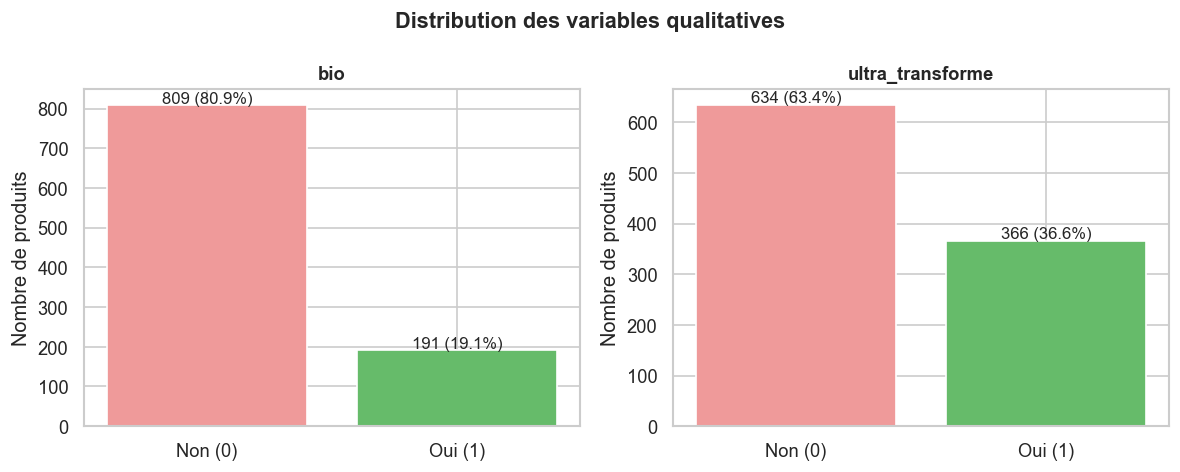

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, var in enumerate(vars_quali):
    freq = df[var].value_counts().sort_index()
    axes[i].bar(["Non (0)", "Oui (1)"], freq.values, color=["#ef9a9a", "#66bb6a"], edgecolor="white")
    for j, v in enumerate(freq.values):
        axes[i].text(j, v + 5, f"{v} ({100*v/len(df):.1f}%)", ha="center", fontsize=10)
    axes[i].set_title(var, fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Nombre de produits")
plt.suptitle("Distribution des variables qualitatives", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig3_barplots_quali.png"))
plt.show()

**Interprétation :**

- **Bio :** seulement ~19% des produits sont biologiques. Ces produits tendent à avoir moins d'additifs et de meilleurs profils nutritionnels.
- **Ultra-transformé :** ~37% des produits sont ultra-transformés (classification NOVA). Ce taux élevé reflète la structure de l'offre alimentaire moderne.

### 2.4 Matrice de corrélation — Analyse de la multicolinéarité

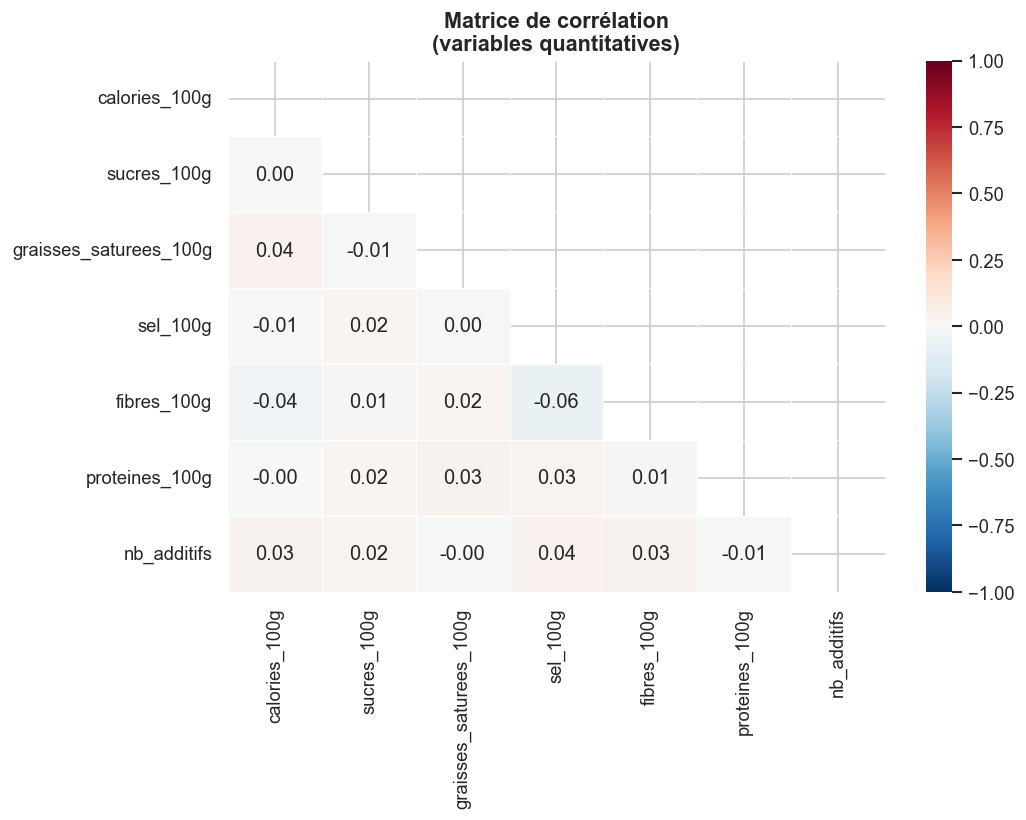

In [12]:
corr_matrix = df[vars_quanti].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Matrice de corrélation\n(variables quantitatives)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig4_correlation.png"))
plt.show()

In [13]:
# Seuil conservateur de 0.5 (plus strict que le 0.7/0.8 souvent utilisé en économétrie)
seuil = 0.5
paires_fortes = []
for i in range(len(vars_quanti)):
    for j in range(i+1, len(vars_quanti)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > seuil:
            paires_fortes.append((vars_quanti[i], vars_quanti[j], r))

if paires_fortes:
    print(f"Corrélations > {seuil} (risque de multicolinéarité) :")
    for v1, v2, r in paires_fortes:
        print(f"  {v1} — {v2} : r = {r:.3f}")
else:
    print(f"Aucune corrélation > {seuil} détectée.")
    print("→ On ne soupçonne pas de multicolinéarité forte, à confirmer lors de l'estimation.")
    print("  Toutes les variables peuvent être incluses en première approche.")

Aucune corrélation > 0.5 détectée.
→ On ne soupçonne pas de multicolinéarité forte, à confirmer lors de l'estimation.
  Toutes les variables peuvent être incluses en première approche.


### 2.5 Tests de moyenne (ANOVA) — Variables quantitatives vs Y

**Hypothèses :**
- **H₀ :** la moyenne de X est identique dans toutes les catégories de Y
- **H₁ :** au moins une catégorie a une moyenne différente

Si p-value < 0.05, on rejette H₀ → la variable discrimine bien les catégories de score Yuka → pertinente pour le modèle.

In [14]:
groupes_y = [df[df["score_yuka_ordonne"] == k] for k in [1, 2, 3, 4]]
vars_sig_anova = []

resultats_anova = []
for var in vars_quanti:
    groupes = [g[var].values for g in groupes_y]
    f_stat, p_val = f_oneway(*groupes)
    sig = "✅ OUI" if p_val < 0.05 else "❌ NON"
    if p_val < 0.05:
        vars_sig_anova.append(var)
    resultats_anova.append({"Variable": var, "F-stat": round(f_stat, 3), "p-value": round(p_val, 4), "Significatif ?": sig})

display(pd.DataFrame(resultats_anova).set_index("Variable"))

,F-stat,p-value,Significatif ?
Variable,,,
calories_100g,139.724,0.0,✅ OUI
sucres_100g,48.672,0.0,✅ OUI
graisses_saturees_100g,29.117,0.0,✅ OUI
sel_100g,31.160,0.0,✅ OUI
fibres_100g,21.899,0.0,✅ OUI
proteines_100g,15.302,0.0,✅ OUI
nb_additifs,55.203,0.0,✅ OUI


**Interprétation ANOVA :**

Pour chaque variable significative, on rejette H₀ : la moyenne de X diffère selon la catégorie Yuka. Ces variables discriminent bien les produits selon leur score.

→ Toutes les variables quantitatives sont significatives au seuil de 5%.  
→ Ces résultats suggèrent des différences de moyennes entre classes, **sans préjuger de la forme fonctionnelle du modèle**.

### 2.6 Tests Chi² — Variables qualitatives vs Y

**Hypothèses :**
- **H₀ :** X et Y sont indépendantes
- **H₁ :** X et Y sont liées

Si p-value < 0.05, on rejette H₀ → la variable qualitative est liée au score Yuka.

In [15]:
resultats_chi2 = []
for var in vars_quali:
    table = pd.crosstab(df[var], df["score_yuka_ordonne"])
    chi2, p, dof, expected = chi2_contingency(table)
    sig = "✅ OUI" if p < 0.05 else "❌ NON"
    resultats_chi2.append({"Variable": var, "Chi²": round(chi2, 3), "p-value": round(p, 4), "Significatif ?": sig})

display(pd.DataFrame(resultats_chi2).set_index("Variable"))

,Chi²,p-value,Significatif ?
Variable,,,
bio,20.618,0.0001,✅ OUI
ultra_transforme,89.207,0.0000,✅ OUI


In [16]:
# Tableaux croisés (fréquences en %)
for var in vars_quali:
    table = pd.crosstab(df[var], df["score_yuka_ordonne"],
                        rownames=[var], colnames=["Score Yuka"],
                        normalize="index") * 100
    table.index = ["Non (0)", "Oui (1)"]
    table.columns = ["Mauvais", "Médiocre", "Bon", "Excellent"]
    print(f"\n{var} — répartition par score Yuka (%) :")
    display(table.round(1))


bio — répartition par score Yuka (%) :


,Mauvais,Médiocre,Bon,Excellent
Non (0),39.3,27.2,22.1,11.4
Oui (1),26.2,25.7,26.7,21.5



ultra_transforme — répartition par score Yuka (%) :


,Mauvais,Médiocre,Bon,Excellent
Non (0),27.0,27.6,27.4,18.0
Oui (1),53.8,25.7,15.3,5.2


**Interprétation Chi² :**

On rejette H₀ pour `bio` et `ultra_transforme` : ces deux variables sont **significativement liées** au score Yuka.
- Un produit bio tend à obtenir un **meilleur** score.
- Un produit ultra-transformé tend à obtenir un **moins bon** score — cohérent avec la littérature sur la qualité nutritionnelle.

→ Les deux variables seront incluses dans le modèle.

---
## Partie 3 — Analyse exploratoire approfondie

### 3.1 Boxplots : variables quantitatives par catégorie Yuka

Ces graphiques permettent de visualiser directement comment chaque variable se distribue selon le score Yuka. C'est la preuve visuelle des résultats ANOVA.

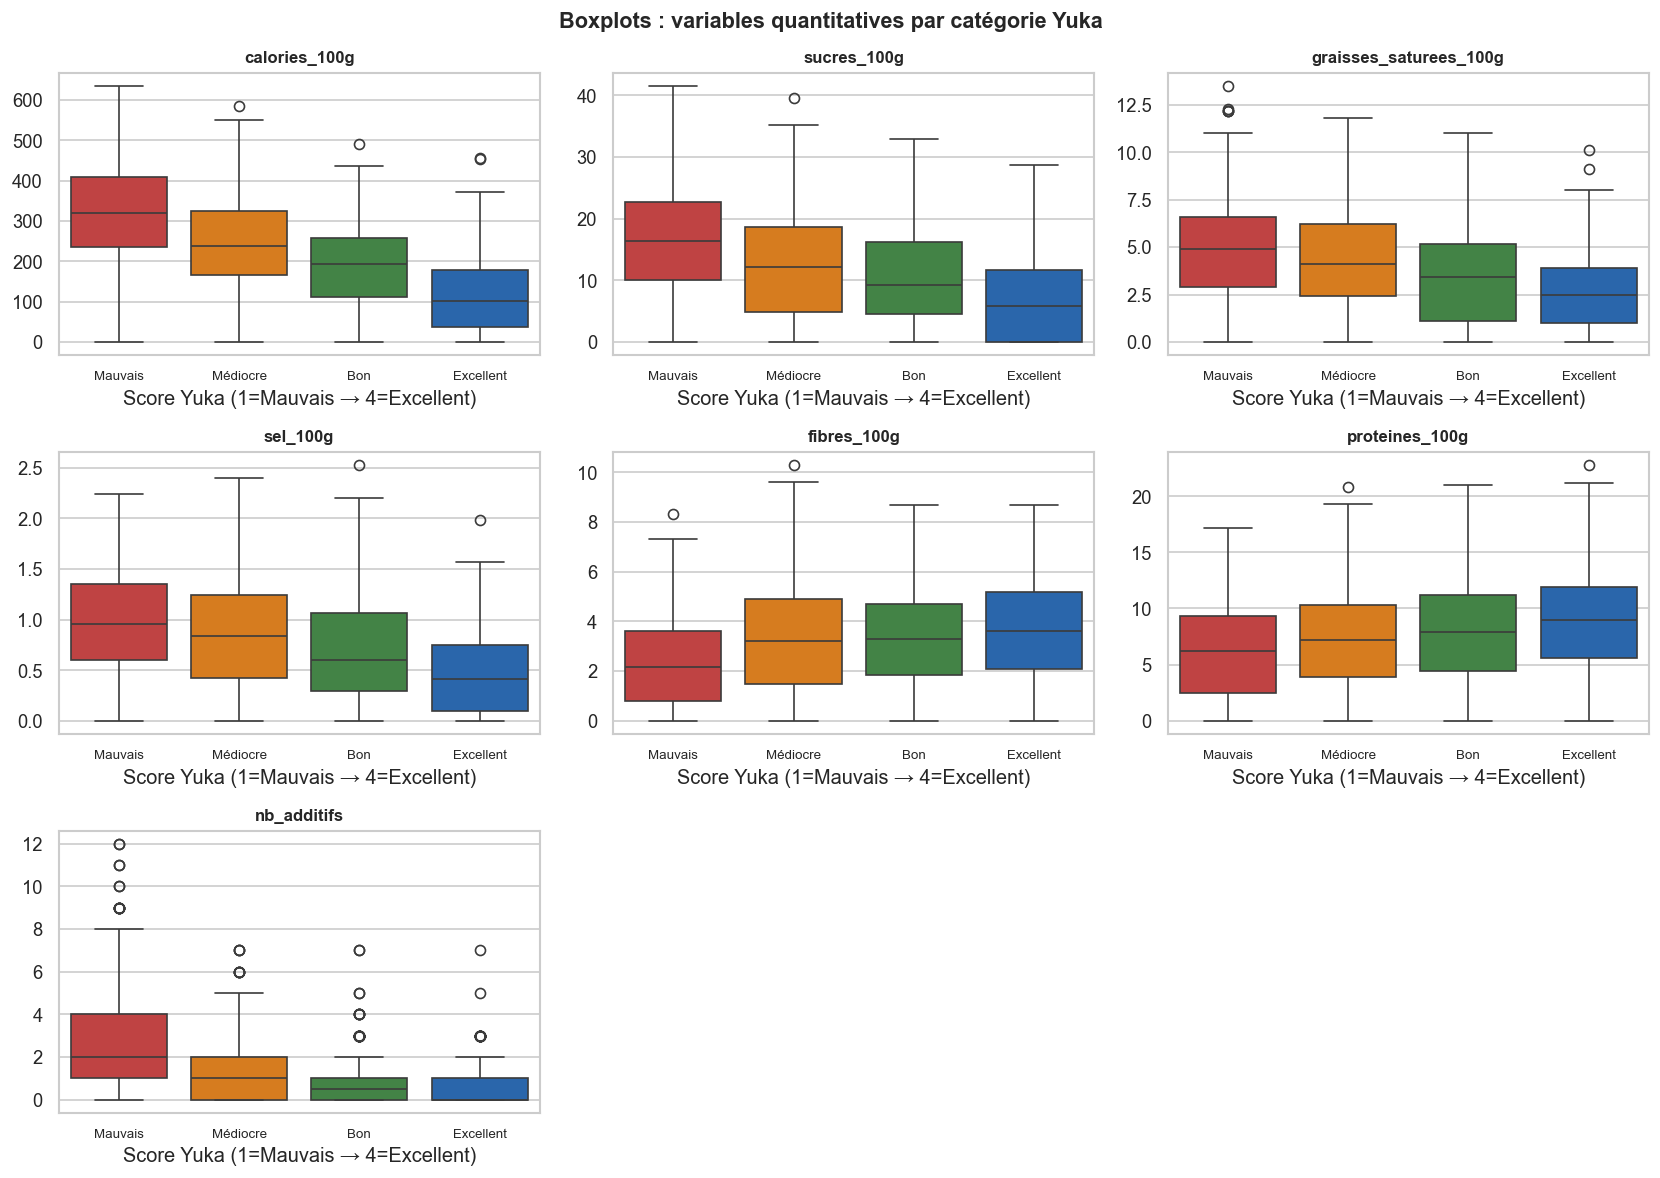

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
colors_box = ["#d32f2f", "#f57c00", "#388e3c", "#1565c0"]

for i, var in enumerate(vars_quanti):
    sns.boxplot(data=df, x="score_yuka_ordonne", y=var, palette=colors_box, ax=axes[i])
    axes[i].set_title(var, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Score Yuka (1=Mauvais → 4=Excellent)")
    axes[i].set_ylabel("")
    axes[i].set_xticklabels(["Mauvais", "Médiocre", "Bon", "Excellent"], fontsize=8)

for j in range(len(vars_quanti), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots : variables quantitatives par catégorie Yuka", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig5_boxplots_par_categorie.png"))
plt.show()

### 3.2 Moyennes par catégorie Yuka

In [18]:
moyennes = df.groupby("score_yuka_ordonne")[vars_quanti].mean()
moyennes.index = ["Mauvais", "Médiocre", "Bon", "Excellent"]
display(moyennes.round(3))

,calories_100g,sucres_100g,graisses_saturees_100g,sel_100g,fibres_100g,proteines_100g,nb_additifs
Mauvais,322.775,16.417,4.876,0.968,2.357,6.118,2.652
Médiocre,245.078,12.220,4.213,0.863,3.297,7.337,1.297
Bon,187.263,10.589,3.396,0.715,3.364,7.952,0.926
Excellent,115.777,6.927,2.719,0.479,3.724,8.971,0.857


In [19]:
print("Lecture économique des tendances :\n")
for var in vars_quanti:
    vals = moyennes[var].values
    tendance = "↘ décroissante" if vals[-1] < vals[0] else "↗ croissante"
    if var in ["fibres_100g", "proteines_100g"]:
        effet = "effet POSITIF attendu"
    elif var in ["sucres_100g", "sel_100g", "graisses_saturees_100g", "nb_additifs"]:
        effet = "effet NÉGATIF attendu"
    elif var == "calories_100g":
        effet = "effet ambigu ou faible"
    else:
        effet = "à vérifier"
    print(f"  {var:<35} tendance {tendance} → {effet}")

Lecture économique des tendances :

  calories_100g                       tendance ↘ décroissante → effet ambigu ou faible
  sucres_100g                         tendance ↘ décroissante → effet NÉGATIF attendu
  graisses_saturees_100g              tendance ↘ décroissante → effet NÉGATIF attendu
  sel_100g                            tendance ↘ décroissante → effet NÉGATIF attendu
  fibres_100g                         tendance ↗ croissante → effet POSITIF attendu
  proteines_100g                      tendance ↗ croissante → effet POSITIF attendu
  nb_additifs                         tendance ↘ décroissante → effet NÉGATIF attendu


**Interprétation :**

- Les produits classés **Mauvais** ont en moyenne plus de sucres, sel, graisses saturées et additifs — tous reconnus comme facteurs de risque pour la santé.
- Les produits **Excellent** ont plus de fibres et de protéines, associés à une meilleure qualité nutritionnelle.
- Cette analyse confirme nos hypothèses économiques et valide l'inclusion de toutes les variables dans le modèle.

### 3.3 Proportion bio et ultra-transformé par catégorie

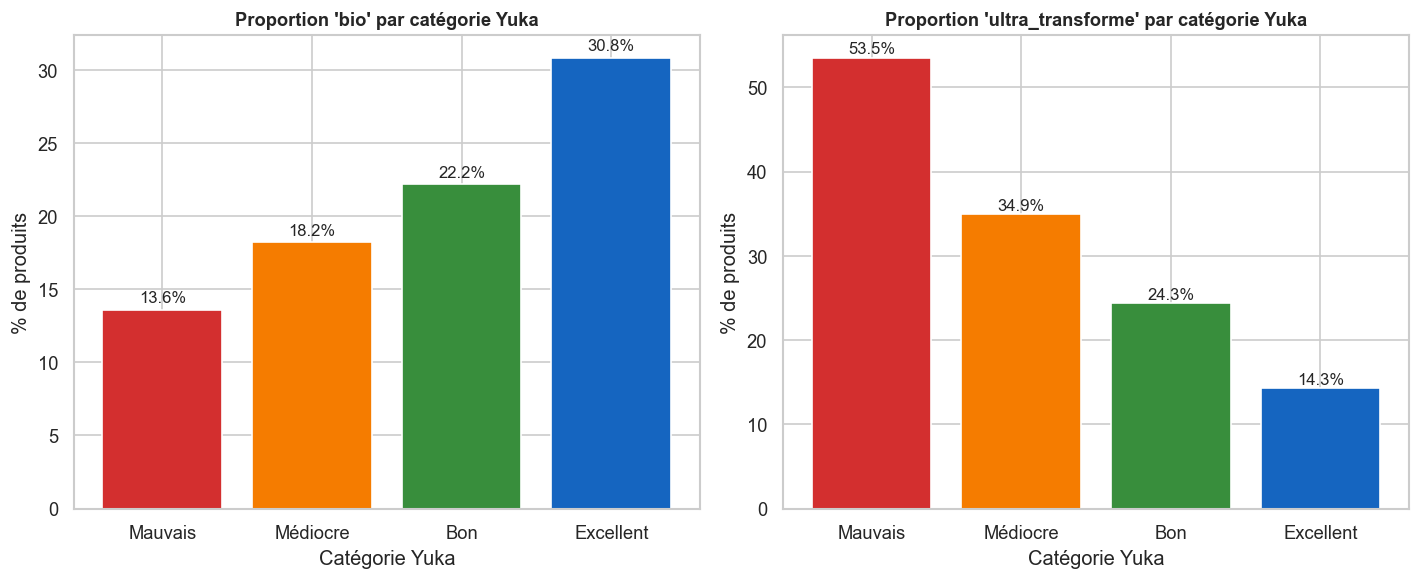

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, var in enumerate(vars_quali):
    prop = df.groupby("score_yuka_ordonne")[var].mean() * 100
    axes[i].bar(["Mauvais", "Médiocre", "Bon", "Excellent"],
                prop.values, color=["#d32f2f", "#f57c00", "#388e3c", "#1565c0"], edgecolor="white")
    for j, v in enumerate(prop.values):
        axes[i].text(j, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)
    axes[i].set_title(f"Proportion '{var}' par catégorie Yuka", fontsize=11, fontweight="bold")
    axes[i].set_ylabel("% de produits")
    axes[i].set_xlabel("Catégorie Yuka")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig6_quali_par_categorie.png"))
plt.show()

**Interprétation :**

- **bio :** la proportion augmente de ~13.6% (Mauvais) à ~30.8% (Excellent). Être bio est associé à de meilleures pratiques de production et moins d'intrants chimiques.
- **ultra_transforme :** la proportion chute de ~53.5% (Mauvais) à ~14.3% (Excellent). La transformation industrielle intensive dégrade la qualité nutritionnelle.

---
## Synthèse — Hypothèses économiques et variables retenues

Cette analyse exploratoire permet d'éviter un modèle mal spécifié.

In [21]:
print("Variables à effet NÉGATIF attendu sur le score Yuka :")
neg = ["sucres_100g", "sel_100g", "graisses_saturees_100g", "nb_additifs", "ultra_transforme"]
for v in neg:
    print(f"  - {v}")

print("\nVariables à effet POSITIF attendu sur le score Yuka :")
pos = ["fibres_100g", "proteines_100g", "bio"]
for v in pos:
    print(f"  - {v}")

print("\nVariables à effet ambigu :")
print("  - calories_100g : significatif statistiquement mais tendance peu claire économiquement")

print(f"\nMulticolinéarité : corrélation max = {corr_matrix.abs().where(~np.eye(len(vars_quanti),dtype=bool)).max().max():.2f}")
print("→ Aucune corrélation élevée (seuil conservateur 0.5) — à confirmer lors de l'estimation.")
print("\n→ Toutes les variables sont retenues pour le modèle Logit Ordonné.")

Variables à effet NÉGATIF attendu sur le score Yuka :
  - sucres_100g
  - sel_100g
  - graisses_saturees_100g
  - nb_additifs
  - ultra_transforme

Variables à effet POSITIF attendu sur le score Yuka :
  - fibres_100g
  - proteines_100g
  - bio

Variables à effet ambigu :
  - calories_100g : significatif statistiquement mais tendance peu claire économiquement

Multicolinéarité : corrélation max = 0.06
→ Aucune corrélation élevée (seuil conservateur 0.5) — à confirmer lors de l'estimation.

→ Toutes les variables sont retenues pour le modèle Logit Ordonné.


**Conclusion de l'analyse exploratoire :**

Les statistiques descriptives nous permettent d'identifier les variables pertinentes avant l'estimation économétrique. Cette analyse exploratoire permet d'éviter un modèle mal spécifié. L'ensemble des variables présente une relation significative avec le score Yuka, ce qui justifie leur inclusion dans le modèle Logit Ordonné.

**Limite à garder en tête :** les résultats restent descriptifs et peuvent être influencés par des variables omises (catégorie de produit, marque, prix). L'estimation économétrique permettra de contrôler ces effets partiellement.

---


# Partie 2 : Méthodologie économétrique (Havar)

## Modèle économétrique

La variable dépendante `score_yuka_ordonne` est une variable qualitative ordonnée :
- 1 = Mauvais
- 2 = Médiocre
- 3 = Bon
- 4 = Excellent

Un modèle de **logit ordonné (Ordered Logit)** est utilisé pour expliquer la probabilité d’appartenir à ces catégories.

In [23]:
import pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel

# Charger les données
df = pd.read_csv('jeu_donnees_yuka.csv', sep=';')

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'jeu_donnees_yuka.csv'

## Variable dépendante

La variable expliquée est `score_yuka_ordonne`.

In [ ]:
y = df['score_yuka_ordonne']

## Modèle 1 : modèle complet

Toutes les variables sont incluses (nutritionnelles + qualitatives).

In [ ]:
X1 = df[['graisses_saturees_100g',
         'sel_100g',
         'fibres_100g',
         'proteines_100g',
         'nb_additifs',
         'bio',
         'ultra_transforme']]

model1 = OrderedModel(y, X1, distr='logit')
res1 = model1.fit(method='bfgs')

print(res1.summary())

Optimization terminated successfully.
         Current function value: 1.025752
         Iterations: 31
         Function evaluations: 33
         Gradient evaluations: 33
                             OrderedModel Results                             
Dep. Variable:     score_yuka_ordonne   Log-Likelihood:                -1025.8
Model:                   OrderedModel   AIC:                             2072.
Method:            Maximum Likelihood   BIC:                             2121.
Date:                Mon, 04 May 2026                                         
Time:                        10:42:05                                         
No. Observations:                1000                                         
Df Residuals:                     990                                         
Df Model:                           7                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------

## Modèle 2 : nutrition seule

On exclut les variables qualitatives (bio, ultra-transformé).

In [ ]:
X2 = df[['graisses_saturees_100g',
         'sel_100g',
         'fibres_100g',
         'proteines_100g']]

model2 = OrderedModel(y, X2, distr='logit')
res2 = model2.fit(method='bfgs')

print(res2.summary())

Optimization terminated successfully.
         Current function value: 1.179019
         Iterations: 21
         Function evaluations: 23
         Gradient evaluations: 23
                             OrderedModel Results                             
Dep. Variable:     score_yuka_ordonne   Log-Likelihood:                -1179.0
Model:                   OrderedModel   AIC:                             2372.
Method:            Maximum Likelihood   BIC:                             2406.
Date:                Mon, 04 May 2026                                         
Time:                        10:42:27                                         
No. Observations:                1000                                         
Df Residuals:                     993                                         
Df Model:                           4                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------

## Modèle 3 : sans ultra-transformé

On garde bio mais on enlève ultra-transformé.

In [ ]:
X3 = df[['graisses_saturees_100g',
         'sel_100g',
         'fibres_100g',
         'proteines_100g',
         'bio']]

model3 = OrderedModel(y, X3, distr='logit')
res3 = model3.fit(method='bfgs')

print(res3.summary())

Optimization terminated successfully.
         Current function value: 1.165142
         Iterations: 26
         Function evaluations: 28
         Gradient evaluations: 28
                             OrderedModel Results                             
Dep. Variable:     score_yuka_ordonne   Log-Likelihood:                -1165.1
Model:                   OrderedModel   AIC:                             2346.
Method:            Maximum Likelihood   BIC:                             2386.
Date:                Mon, 04 May 2026                                         
Time:                        10:43:03                                         
No. Observations:                1000                                         
Df Residuals:                     992                                         
Df Model:                           5                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------

## Interprétation des résultats

- Les graisses saturées et le sel ont un effet négatif sur le score Yuka.
- Les fibres et les protéines ont un effet positif.
- Les produits bio ont une probabilité plus élevée d’obtenir une bonne note.
- Les produits ultra-transformés ont un effet négatif significatif.

Toutes les variables sont statistiquement significatives (p < 0.05).

# Mouhammad # Partie 3 — Évaluation, interprétation et choix du modèle final

Cette partie s’appuie sur les trois modèles logit ordonné estimés précédemment.

L’objectif est d’évaluer la qualité statistique de ces modèles, de comparer leurs performances, d’interpréter économiquement les résultats obtenus et de justifier le choix du modèle final.

La variable dépendante est `score_yuka_ordonne`, une variable qualitative ordonnée allant de 1 à 4 :

- 1 = Mauvais  
- 2 = Médiocre  
- 3 = Bon  
- 4 = Excellent  

Trois spécifications du modèle ont été retenues :

- **Modèle 1 : modèle complet**, incluant les graisses saturées, le sel, les fibres, les protéines, le nombre d’additifs, le caractère biologique du produit et le caractère ultra-transformé ;
- **Modèle 2 : modèle nutritionnel**, limité aux variables nutritionnelles principales : graisses saturées, sel, fibres et protéines ;
- **Modèle 3 : modèle intermédiaire**, qui reprend les variables nutritionnelles du modèle 2 en ajoutant la variable `bio`.

Ces différentes spécifications permettent de vérifier si l’ajout de variables qualitatives améliore la qualité du modèle et d’identifier la spécification la plus pertinente pour expliquer la notation Yuka.

In [ ]:
import pandas as pd
import numpy as np

from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
import os

os.chdir(r"C:\Users\gayem\jeu_donnees_YUKA")
print(os.getcwd())

C:\Users\gayem\jeu_donnees_YUKA


# Chargement de la base clean

In [ ]:
df = pd.read_csv("data/jeu_donnees_yuka.csv", sep=";")
df.head()

,id_produit,calories_100g,sucres_100g,graisses_saturees_100g,sel_100g,fibres_100g,proteines_100g,nb_additifs,bio,ultra_transforme,score_yuka_ordonne,classe_yuka
0,1,229.8,10.3,3.7,1.22,2.7,0.0,4,1,1,1,Mauvais
1,2,282.5,23.6,6.0,0.87,1.2,1.9,0,0,0,1,Mauvais
2,3,446.7,32.8,3.3,1.03,7.0,12.5,2,0,0,1,Mauvais
3,4,121.8,20.8,6.0,0.07,5.1,2.0,2,1,1,2,Médiocre
4,5,257.0,16.6,3.3,1.64,1.4,10.6,0,0,0,2,Médiocre


# Modèles de Havar

In [ ]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

# Variable dépendante
y = df['score_yuka_ordonne']

# -------------------------
# MODELE 1 : COMPLET
# -------------------------
X1 = df[['graisses_saturees_100g',
         'sel_100g',
         'fibres_100g',
         'proteines_100g',
         'nb_additifs',
         'bio',
         'ultra_transforme']]

model1 = OrderedModel(y, X1, distr='logit')
res1 = model1.fit(method='bfgs')

# -------------------------
# MODELE 2 : NUTRITION
# -------------------------
X2 = df[['graisses_saturees_100g',
         'sel_100g',
         'fibres_100g',
         'proteines_100g']]

model2 = OrderedModel(y, X2, distr='logit')
res2 = model2.fit(method='bfgs')

# -------------------------
# MODELE 3 : INTERMEDIAIRE
# -------------------------
X3 = df[['graisses_saturees_100g',
         'sel_100g',
         'fibres_100g',
         'proteines_100g',
         'bio']]

model3 = OrderedModel(y, X3, distr='logit')
res3 = model3.fit(method='bfgs')

Optimization terminated successfully.
         Current function value: 1.025752
         Iterations: 31
         Function evaluations: 33
         Gradient evaluations: 33
Optimization terminated successfully.
         Current function value: 1.179019
         Iterations: 21
         Function evaluations: 23
         Gradient evaluations: 23
Optimization terminated successfully.
         Current function value: 1.165142
         Iterations: 26
         Function evaluations: 28
         Gradient evaluations: 28


# 6. Évaluation du modèle

# 6. Évaluation des modèles

L’évaluation des modèles permet de vérifier si les différentes spécifications du modèle logit ordonné estimées sont statistiquement satisfaisantes et économiquement pertinentes.

Dans cette partie, nous analysons d’abord la significativité des coefficients pour chaque modèle, puis nous comparons leur qualité à l’aide de critères d’information.

Cette démarche permet d’identifier le modèle le plus performant pour expliquer la notation Yuka.

# 6.1 Tests 
Les tests de significativité permettent d’évaluer si les variables explicatives retenues contribuent réellement à expliquer la notation Yuka.

Nous analysons d’abord la significativité individuelle des coefficients à partir des p-values, puis la significativité globale des modèles à l’aide du test du ratio de vraisemblance.

In [ ]:
def tableau_pvalues(resultat, nom_modele):
    table = pd.DataFrame({
        "Variable": resultat.params.index,
        "Coefficient": resultat.params.values,
        "P-value": resultat.pvalues.values
    })
    table["Modèle"] = nom_modele
    return table

pvalues_m1 = tableau_pvalues(res1, "Modèle 1 - Complet")
pvalues_m2 = tableau_pvalues(res2, "Modèle 2 - Nutrition")
pvalues_m3 = tableau_pvalues(res3, "Modèle 3 - Intermédiaire")

pvalues_comparaison = pd.concat([pvalues_m1, pvalues_m2, pvalues_m3], ignore_index=True)

pvalues_comparaison

,Variable,Coefficient,P-value,Modèle
0,graisses_saturees_100g,-0.301962,4.314520e-32,Modèle 1 - Complet
1,sel_100g,-1.238023,1.529105e-24,Modèle 1 - Complet
2,fibres_100g,0.312079,1.838324e-23,Modèle 1 - Complet
3,proteines_100g,0.135298,9.286063e-22,Modèle 1 - Complet
4,nb_additifs,-0.443770,1.331477e-24,Modèle 1 - Complet
5,bio,1.108518,1.219418e-11,Modèle 1 - Complet
6,ultra_transforme,-1.114221,3.064165e-14,Modèle 1 - Complet
7,1/2,-2.038488,1.917137e-20,Modèle 1 - Complet
8,2/3,0.555057,2.739120e-23,Modèle 1 - Complet
9,3/4,0.621046,6.539069e-25,Modèle 1 - Complet



### 6.1.1 Tests individuels : p-values

L’analyse des p-values montre que l’ensemble des variables explicatives est statistiquement significatif au seuil de 5 % dans les trois modèles estimés.

En effet, toutes les p-values sont largement inférieures à 0.05, ce qui permet de rejeter l’hypothèse nulle selon laquelle les coefficients sont nuls.  
Ainsi, les variables retenues contribuent significativement à l’explication du score Yuka.

Les résultats sont globalement cohérents entre les différents modèles :

- Les variables nutritionnelles telles que les graisses saturées et le sel ont un effet négatif sur la probabilité d’obtenir une bonne note.
- Les fibres et les protéines ont un effet positif, indiquant une amélioration de la qualité nutritionnelle.
- Les variables qualitatives comme le caractère bio ont un effet positif, tandis que les produits ultra-transformés ont un effet négatif.

Les seuils (1/2, 2/3, 3/4) correspondent aux paramètres de coupure du modèle logit ordonné.  
Ils permettent de délimiter les différentes catégories de la variable dépendante et ne s’interprètent pas comme des variables explicatives.

Enfin, la stabilité des signes et de la significativité des coefficients entre les modèles indique une certaine robustesse des résultats.

#  6.1.2 Test global : Likelihood Ratio

In [ ]:
import scipy.stats as stats

def lr_test(resultat, X, y):
    ll_full = resultat.llf
    
    # Approximation du modèle nul : répartition uniforme entre les catégories
    n = len(y)
    k = len(np.unique(y))
    ll_null = -n * np.log(k)
    
    LR_stat = 2 * (ll_full - ll_null)
    ddl = X.shape[1]
    p_value = stats.chi2.sf(LR_stat, ddl)
    
    return LR_stat, ddl, p_value

lr1 = lr_test(res1, X1, y)
lr2 = lr_test(res2, X2, y)
lr3 = lr_test(res3, X3, y)

lr_table = pd.DataFrame({
    "Modèle": ["Modèle 1 - Complet", "Modèle 2 - Nutrition", "Modèle 3 - Intermédiaire"],
    "Statistique LR": [lr1[0], lr2[0], lr3[0]],
    "Degrés de liberté": [lr1[1], lr2[1], lr3[1]],
    "P-value": [lr1[2], lr2[2], lr3[2]]
})

lr_table

,Modèle,Statistique LR,Degrés de liberté,P-value
0,Modèle 1 - Complet,721.084365,7,1.960411e-151
1,Modèle 2 - Nutrition,414.549737,4,1.996666e-88
2,Modèle 3 - Intermédiaire,442.304994,5,2.244062e-93



Le test du ratio de vraisemblance permet d’évaluer la significativité globale des modèles en comparant chaque modèle estimé à un modèle nul ne contenant aucune variable explicative.

L’hypothèse nulle stipule que l’ensemble des coefficients des variables explicatives est nul.  
Une p-value faible conduit à rejeter cette hypothèse.

Les résultats obtenus montrent que les trois modèles sont globalement significatifs :

- Modèle 1 (complet) : statistique LR = 721.08, p-value ≈ 0  
- Modèle 2 (nutrition) : statistique LR = 414.55, p-value ≈ 0  
- Modèle 3 (intermédiaire) : statistique LR = 442.30, p-value ≈ 0  

Dans tous les cas, les p-values sont extrêmement faibles (proches de zéro), ce qui permet de rejeter l’hypothèse nulle au seuil de 5 %.  
Ainsi, les variables explicatives introduites dans chaque modèle contribuent significativement à expliquer la notation Yuka.

Par ailleurs, le modèle 1 présente la statistique LR la plus élevée, ce qui indique qu’il améliore davantage la vraisemblance par rapport au modèle nul.  
Cela suggère que le modèle complet possède un pouvoir explicatif supérieur aux modèles réduits.

Toutefois, ce critère devra être complété par l’analyse des critères d’information afin de tenir compte de la complexité des modèles.

## 6.2 Critères de qualité des modèles

Après avoir étudié la significativité individuelle et globale des modèles, nous comparons maintenant leur qualité d’ajustement.

Pour cela, nous utilisons plusieurs indicateurs :

- le critère AIC, qui permet de comparer les modèles en tenant compte de leur qualité d’ajustement et de leur complexité ;
- le critère BIC, qui pénalise davantage les modèles comportant plus de variables ;
- la log-vraisemblance, qui mesure la capacité du modèle à expliquer les données observées ;
- le pseudo R² de McFadden, qui donne une indication globale du pouvoir explicatif du modèle.

Ces critères permettent de comparer les différentes spécifications et d’identifier le modèle présentant le meilleur compromis entre performance statistique et parcimonie.

In [ ]:

# Critères de qualité

# AIC
aic1 = res1.aic
aic2 = res2.aic
aic3 = res3.aic

# BIC
bic1 = res1.bic
bic2 = res2.bic
bic3 = res3.bic

# Log-vraisemblance
ll1 = res1.llf
ll2 = res2.llf
ll3 = res3.llf

# Log-vraisemblance du modèle nul
# Approximation utilisée : répartition uniforme entre les catégories
n = len(y)
k = len(np.unique(y))
ll_null = -n * np.log(k)

# Pseudo R² de McFadden
pseudo_r2_1 = 1 - (ll1 / ll_null)
pseudo_r2_2 = 1 - (ll2 / ll_null)
pseudo_r2_3 = 1 - (ll3 / ll_null)

# Tableau récapitulatif
qualite_modeles = pd.DataFrame({
    "Modèle": [
        "Modèle 1 - Complet",
        "Modèle 2 - Nutrition",
        "Modèle 3 - Intermédiaire"
    ],
    "Log-vraisemblance": [ll1, ll2, ll3],
    "AIC": [aic1, aic2, aic3],
    "BIC": [bic1, bic2, bic3],
    "Pseudo R² de McFadden": [pseudo_r2_1, pseudo_r2_2, pseudo_r2_3]
})

qualite_modeles

,Modèle,Log-vraisemblance,AIC,BIC,Pseudo R² de McFadden
0,Modèle 1 - Complet,-1025.752179,2071.504357,2120.581910,0.260076
1,Modèle 2 - Nutrition,-1179.019493,2372.038986,2406.393273,0.149517
2,Modèle 3 - Intermédiaire,-1165.141864,2346.283728,2385.545770,0.159528



L’analyse des critères d’information permet de comparer les performances des trois modèles estimés.

Le modèle 1 (complet) présente la log-vraisemblance la plus élevée (en valeur absolue la moins négative), ce qui indique qu’il s’ajuste mieux aux données observées que les autres modèles.

En ce qui concerne les critères d’information, le modèle 1 présente également les valeurs les plus faibles pour l’AIC (2071.50) et le BIC (2120.58).  
Cela signifie qu’il offre le meilleur compromis entre qualité d’ajustement et complexité du modèle.

Les modèles 2 et 3 présentent des AIC et BIC plus élevés, ce qui indique une perte d’information liée à l’exclusion de certaines variables explicatives.

Le pseudo R² de McFadden confirme ces résultats :
- Modèle 1 : 0.260  
- Modèle 2 : 0.150  
- Modèle 3 : 0.160  

Le modèle 1 présente ainsi le pouvoir explicatif le plus élevé parmi les trois spécifications.

La convergence des critères AIC, BIC et pseudo R² vers le modèle 1 renforce la robustesse du choix de ce modèle.

Ainsi, le modèle complet apparaît comme le modèle le plus performant pour expliquer la notation Yuka.

# Visualisation graphique AIC/BIC

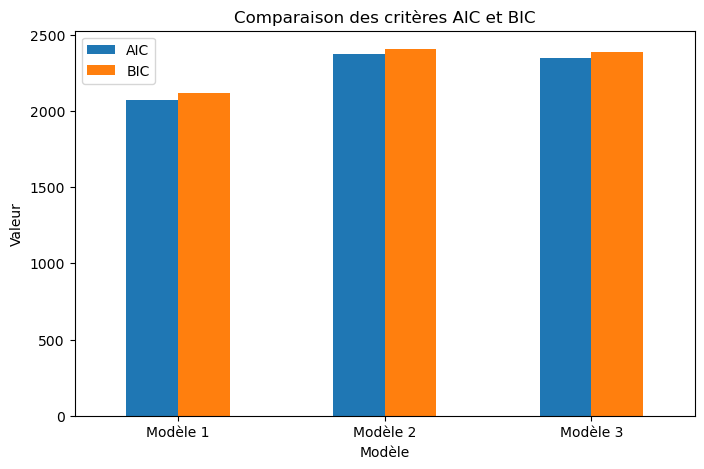

In [ ]:
crit_df = pd.DataFrame({
    "Modèle": ["Modèle 1", "Modèle 2", "Modèle 3"],
    "AIC": [res1.aic, res2.aic, res3.aic],
    "BIC": [res1.bic, res2.bic, res3.bic]
})

crit_df.set_index("Modèle").plot(kind="bar", figsize=(8,5))
plt.title("Comparaison des critères AIC et BIC")
plt.ylabel("Valeur")
plt.xticks(rotation=0)
plt.show()

## 6.3 Performance prédictive

Au-delà de la significativité statistique et des critères d’information, il est important d’évaluer la capacité prédictive des modèles.

Nous analysons la performance des modèles à partir :
- de la matrice de confusion,
- du taux de bonne classification (accuracy),
- du taux d’erreur.

Ces indicateurs permettent de mesurer dans quelle mesure les modèles sont capables de prédire correctement la catégorie de score Yuka.

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

def evaluation_modele(resultat, X, y):
    # Probabilités prédites
    pred_probs = resultat.predict(X)
    
    # Classe prédite = celle avec proba max
    y_pred = pred_probs.idxmax(axis=1) + 1
    
    # Matrice de confusion
    mat = confusion_matrix(y, y_pred)
    
    # Accuracy
    acc = accuracy_score(y, y_pred)
    
    return mat, acc

# Évaluation des 3 modèles
mat1, acc1 = evaluation_modele(res1, X1, y)
mat2, acc2 = evaluation_modele(res2, X2, y)
mat3, acc3 = evaluation_modele(res3, X3, y)

# Tableau récapitulatif
performance = pd.DataFrame({
    "Modèle": ["Modèle 1 - Complet", "Modèle 2 - Nutrition", "Modèle 3 - Intermédiaire"],
    "Accuracy": [acc1, acc2, acc3],
    "Taux d'erreur": [1-acc1, 1-acc2, 1-acc3]
})

performance

,Modèle,Accuracy,Taux d'erreur
0,Modèle 1 - Complet,0.515,0.485
1,Modèle 2 - Nutrition,0.444,0.556
2,Modèle 3 - Intermédiaire,0.458,0.542



Les résultats de la performance prédictive montrent des différences claires entre les trois modèles estimés.

Le modèle 1 (complet) présente le taux de bonne classification le plus élevé, avec une accuracy de 51,5 %.  
Il est donc le modèle le plus performant pour prédire correctement la notation Yuka.

Les modèles 2 et 3 présentent des performances plus faibles :
- Modèle 2 : accuracy de 44,4 %
- Modèle 3 : accuracy de 45,8 %

Cela indique que l’exclusion de certaines variables, notamment les variables qualitatives, entraîne une perte de capacité prédictive.

Le taux d’erreur est également le plus faible pour le modèle 1 (48,5 %), contre plus de 54 % pour les modèles 2 et 3.

Ainsi, même si les performances globales restent modérées, le modèle complet apparaît comme le plus performant en termes de prédiction.

Ces résultats confirment ceux obtenus précédemment avec les critères AIC, BIC et pseudo R², renforçant la robustesse du choix du modèle 1.

# ROC et AUC

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Classes de la variable ordonnée
classes = sorted(y.unique())

# Binarisation de y pour approche One-vs-Rest
y_bin = label_binarize(y, classes=classes)

def roc_auc_multiclasse(resultat, X, nom_modele):
    # Probabilités prédites
    y_score = resultat.predict(X).values
    
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    for i, classe in enumerate(classes):
        fpr[classe], tpr[classe], _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc[classe] = auc(fpr[classe], tpr[classe])
    
    auc_moyenne = np.mean(list(roc_auc.values()))
    
    return fpr, tpr, roc_auc, auc_moyenne

# Calcul pour les 3 modèles
fpr1, tpr1, auc1, auc_moy1 = roc_auc_multiclasse(res1, X1, "Modèle 1")
fpr2, tpr2, auc2, auc_moy2 = roc_auc_multiclasse(res2, X2, "Modèle 2")
fpr3, tpr3, auc3, auc_moy3 = roc_auc_multiclasse(res3, X3, "Modèle 3")

# Tableau récapitulatif des AUC moyennes
auc_table = pd.DataFrame({
    "Modèle": [
        "Modèle 1 - Complet",
        "Modèle 2 - Nutrition",
        "Modèle 3 - Intermédiaire"
    ],
    "AUC moyenne": [auc_moy1, auc_moy2, auc_moy3]
})

auc_table

,Modèle,AUC moyenne
0,Modèle 1 - Complet,0.772414
1,Modèle 2 - Nutrition,0.689480
2,Modèle 3 - Intermédiaire,0.699730


# Graphique comparaison des AUC moyennes

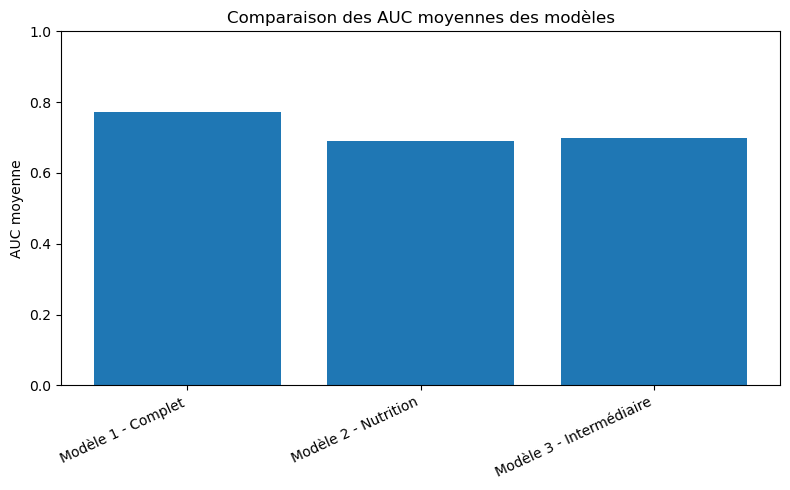

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(auc_table["Modèle"], auc_table["AUC moyenne"])
plt.title("Comparaison des AUC moyennes des modèles")
plt.ylabel("AUC moyenne")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# ROC du modèle 1

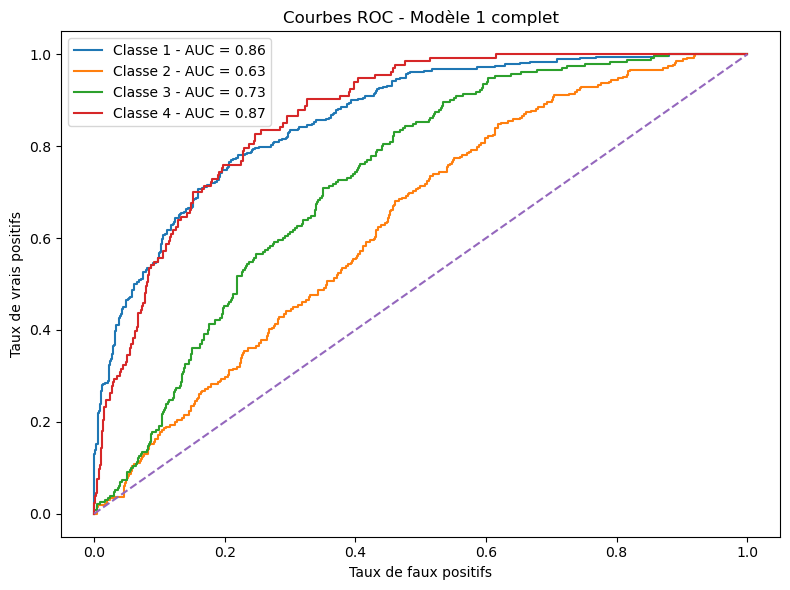

In [ ]:
plt.figure(figsize=(8, 6))

for classe in classes:
    plt.plot(
        fpr1[classe],
        tpr1[classe],
        label=f"Classe {classe} - AUC = {auc1[classe]:.2f}"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC - Modèle 1 complet")
plt.legend()
plt.tight_layout()
plt.show()

# Analyse des courbes ROC et de l’AUC

Afin d’évaluer la performance prédictive des modèles, des courbes ROC ont été construites selon une approche One-vs-Rest, adaptée au cas d’une variable dépendante ordonnée à plusieurs catégories.

L’aire sous la courbe (AUC) permet de mesurer la capacité des modèles à discriminer correctement les différentes classes du score Yuka.

Les résultats obtenus sont les suivants :

- Modèle 1 (complet) : AUC ≈ 0.77  
- Modèle 2 (nutrition) : AUC ≈ 0.69  
- Modèle 3 (intermédiaire) : AUC ≈ 0.70  

Ces résultats montrent que le modèle complet présente la meilleure capacité de discrimination entre les différentes catégories de score.

L’analyse des courbes ROC confirme cette conclusion : les courbes du modèle complet sont globalement plus éloignées de la diagonale, ce qui indique une meilleure performance prédictive.

On observe également que certaines classes sont mieux prédites que d’autres, notamment les classes extrêmes (produits de très bonne ou très mauvaise qualité), ce qui est cohérent avec la structure du score Yuka.

Ainsi, les résultats en termes d’AUC sont cohérents avec les autres critères d’évaluation (AIC, BIC, pseudo R² et taux d’erreur), et confirment la supériorité du modèle complet.

# 7. Interprétation économique

L’interprétation économique des résultats permet de donner un sens concret aux estimations obtenues.

Nous analysons d’abord le signe et la significativité des coefficients, puis nous étudions leur impact sur la probabilité d’obtenir une meilleure note Yuka.

Cette analyse permet de relier les résultats économétriques aux caractéristiques nutritionnelles et qualitatives des produits.

## 7.1 Analyse des coefficients

Les résultats du modèle logit ordonné montrent que les variables nutritionnelles et qualitatives ont des effets significatifs sur la notation Yuka.

Les coefficients négatifs indiquent une diminution de la probabilité d’obtenir une meilleure note, tandis que les coefficients positifs indiquent une amélioration de cette probabilité.

Les principales conclusions sont les suivantes :

- Les graisses saturées et le sel ont un effet négatif sur la qualité du produit.  
- Le nombre d’additifs réduit également la probabilité d’obtenir une bonne note.  
- Le caractère ultra-transformé est fortement associé à une mauvaise notation.  

À l’inverse :

- Les fibres et les protéines ont un effet positif sur la notation.  
- Les produits biologiques ont une probabilité plus élevée d’obtenir une meilleure note.

Ces résultats sont cohérents avec la logique nutritionnelle utilisée par l’application Yuka.

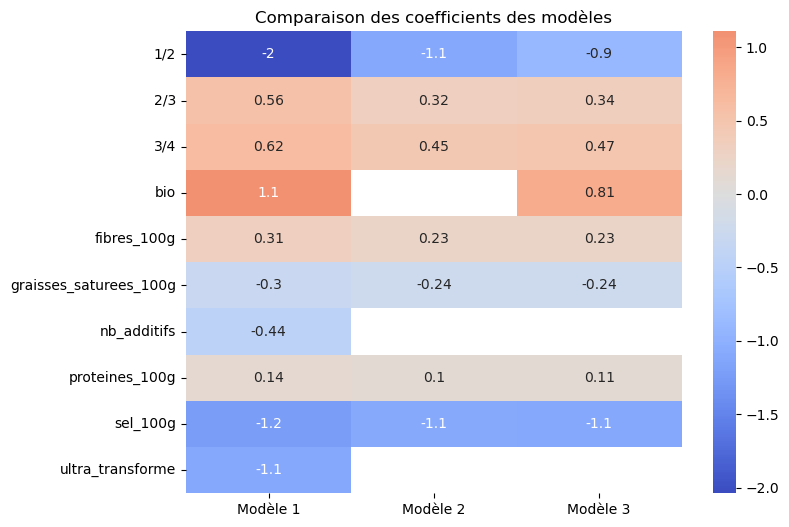

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    "Modèle 1": res1.params,
    "Modèle 2": res2.params,
    "Modèle 3": res3.params
})

plt.figure(figsize=(8,6))
sns.heatmap(coef_df, annot=True, cmap="coolwarm", center=0)
plt.title("Comparaison des coefficients des modèles")
plt.show()


Le graphique ci-dessous présente une comparaison des coefficients estimés pour les différentes spécifications du modèle.

Cette représentation permet de visualiser la stabilité des effets des variables explicatives à travers les modèles.

On observe que :

- Les variables nutritionnelles principales (sel, graisses saturées, fibres, protéines) conservent des signes cohérents dans tous les modèles.
- Le sel et les graisses saturées ont systématiquement un effet négatif sur le score, confirmant leur impact défavorable sur la qualité nutritionnelle.
- Les fibres et les protéines ont un effet positif stable, ce qui reflète leur contribution à une meilleure notation.
- La variable bio présente un effet fortement positif dans les modèles où elle est incluse.
- Les variables liées à la transformation (additifs, ultra-transformé) ont un effet négatif marqué dans le modèle complet.

Ainsi, les résultats apparaissent robustes aux différentes spécifications, ce qui renforce la crédibilité du modèle retenu.

# Les effets marginaux

In [ ]:
# Effets marginaux moyens approximatifs pour le modèle 1
# Méthode : on augmente chaque variable d'une unité et on observe la variation moyenne
# des probabilités prédites pour chaque catégorie Yuka.

def effets_marginaux_moyens(resultat, X, delta=1):
    effets = []

    proba_initiale = resultat.predict(X)

    for var in X.columns:
        X_modifie = X.copy()
        X_modifie[var] = X_modifie[var] + delta

        proba_modifiee = resultat.predict(X_modifie)
        effet_moyen = (proba_modifiee - proba_initiale).mean()

        effets.append(effet_moyen)

    effets_marginaux = pd.DataFrame(effets, index=X.columns)
    effets_marginaux.columns = [f"Effet sur score {i}" for i in sorted(y.unique())]

    return effets_marginaux

effets_m1 = effets_marginaux_moyens(res1, X1)

effets_m1

,Effet sur score 1,Effet sur score 2,Effet sur score 3,Effet sur score 4
graisses_saturees_100g,0.044829,0.000042,-0.020103,-0.024769
sel_100g,0.191123,-0.024046,-0.087268,-0.079809
fibres_100g,-0.044092,-0.004006,0.018571,0.029528
proteines_100g,-0.019425,-0.001255,0.008374,0.012307
nb_additifs,0.066468,-0.001278,-0.030044,-0.035146
bio,-0.143293,-0.030187,0.050861,0.122619
ultra_transforme,0.171581,-0.018880,-0.078479,-0.074222


### Interprétation approfondie des effets marginaux

Les effets marginaux permettent d’évaluer l’impact d’une variation des variables explicatives sur la probabilité d’appartenir à chaque catégorie du score Yuka.

#### Effets des variables nutritionnelles

Les graisses saturées et le sel présentent des effets fortement négatifs sur la qualité nutritionnelle des produits.

- Une augmentation des graisses saturées accroît la probabilité d’obtenir un score faible (score 1) et réduit celle d’obtenir un score élevé (score 4).
- L’effet du sel est encore plus marqué : il augmente fortement la probabilité d’être classé dans les produits de mauvaise qualité (+19,1 points de pourcentage) et diminue significativement la probabilité d’obtenir un bon score.

Ces résultats confirment que ces composantes nutritionnelles constituent des facteurs fortement pénalisants dans l’évaluation Yuka.

À l’inverse :

- Les fibres augmentent la probabilité d’obtenir un score élevé (+2,95 points) et réduisent la probabilité d’un score faible.
- Les protéines ont également un effet positif, bien que plus modéré.

Ces résultats reflètent l’importance des nutriments bénéfiques dans l’amélioration de la qualité perçue des produits.

#### Effets des variables de transformation et de composition

- Le nombre d’additifs augmente la probabilité d’un mauvais score (+6,6 points) et diminue celle d’un bon score.
- Le caractère ultra-transformé a un effet particulièrement négatif, avec une augmentation importante de la probabilité d’un score faible (+17,2 points) et une baisse marquée des scores élevés.

Ces effets mettent en évidence le rôle central du degré de transformation dans l’évaluation des produits alimentaires.

#### Effets des variables qualitatives

- Le label bio réduit fortement la probabilité d’un mauvais score (-14,3 points) et augmente significativement celle d’un excellent score (+12,3 points).

Cela suggère que les produits biologiques sont associés à une meilleure qualité nutritionnelle, ou du moins à une perception positive par le système de notation.

#### Conclusion

Dans l’ensemble, les effets marginaux confirment la cohérence économique du modèle estimé.

Les variables nutritionnelles défavorables (sel, graisses, additifs, transformation) dégradent significativement la qualité des produits, tandis que les variables favorables (fibres, protéines, bio) améliorent leur classification.

Ces résultats sont en parfaite adéquation avec les principes nutritionnels sous-jacents au score Yuka et renforcent la validité du modèle économétrique retenu.

# Visulisation graphique

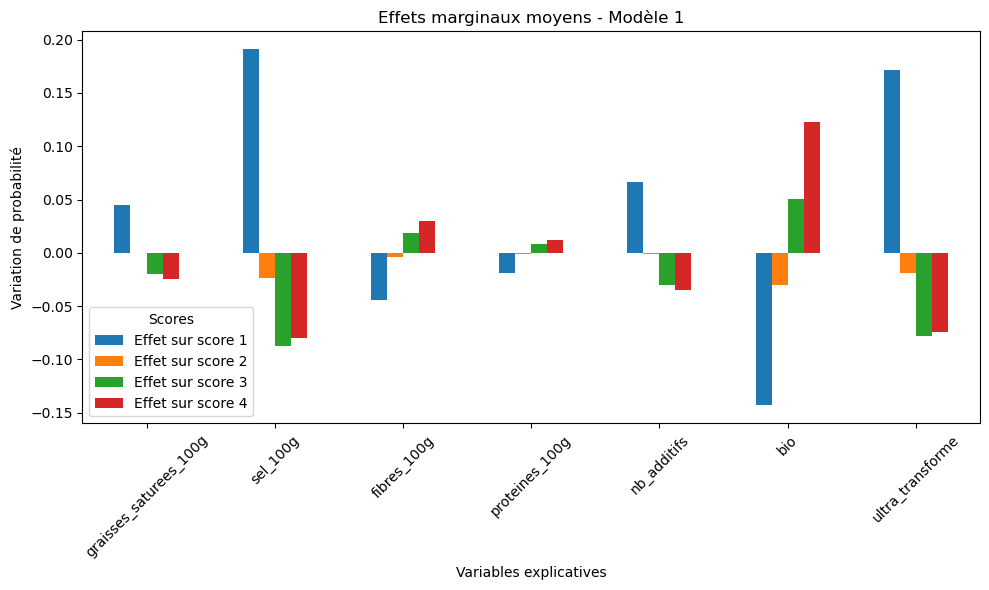

In [ ]:
import matplotlib.pyplot as plt

# Graphique des effets marginaux
effets_m1.plot(kind='bar', figsize=(10,6))

plt.title("Effets marginaux moyens - Modèle 1")
plt.ylabel("Variation de probabilité")
plt.xlabel("Variables explicatives")
plt.xticks(rotation=45)
plt.legend(title="Scores")
plt.tight_layout()

plt.show()

### Analyse graphique des effets marginaux

Le graphique des effets marginaux met en évidence l’impact différencié des variables explicatives sur les probabilités d’appartenance aux différentes catégories du score Yuka.

On observe que certaines variables ont un effet fortement asymétrique :

- Le sel et le caractère ultra-transformé augmentent significativement la probabilité d’obtenir un score faible, tout en réduisant fortement celle d’obtenir un score élevé.  
Ces variables apparaissent comme les principaux facteurs de dégradation de la qualité nutritionnelle.

- À l’inverse, les fibres et le label bio augmentent la probabilité d’obtenir un score élevé et réduisent celle d’un score faible, confirmant leur rôle positif dans la qualité des produits.

- Les protéines et le nombre d’additifs présentent des effets plus modérés, mais restent cohérents avec la logique nutritionnelle.

Le graphique permet ainsi de visualiser clairement la hiérarchie des déterminants du score Yuka, en distinguant les variables fortement pénalisantes des variables améliorant la qualité.

# Les Odds Ratios

In [ ]:
import numpy as np

odds_ratio = np.exp(res1.params)
odds_ratio

graisses_saturees_100g    0.739366
sel_100g                  0.289957
fibres_100g               1.366262
proteines_100g            1.144878
nb_additifs               0.641613
bio                       3.029864
ultra_transforme          0.328171
1/2                       0.130226
2/3                       1.742041
3/4                       1.860873
dtype: float64

### Interprétation des odds ratios

Les odds ratios permettent d’interpréter les coefficients du modèle logit ordonné en termes de rapport de chances.

Un odds ratio supérieur à 1 indique une augmentation des chances d’obtenir un score plus élevé, tandis qu’un odds ratio inférieur à 1 indique une diminution.

Les résultats obtenus sont les suivants :

- Les graisses saturées (0.74) et le sel (0.29) présentent des odds ratios inférieurs à 1, ce qui signifie qu’ils réduisent fortement les chances d’obtenir un bon score.  
  L’effet du sel est particulièrement marqué.

- Les fibres (1.37) et les protéines (1.14) ont des odds ratios supérieurs à 1, indiquant qu’elles augmentent les chances d’obtenir un meilleur score, bien que l’effet des protéines soit plus modéré.

- Le nombre d’additifs (0.64) diminue les chances d’obtenir un bon score, ce qui reflète une perception négative des produits transformés.

- Le label bio (3.03) a un effet très important : il multiplie par plus de 3 les chances d’obtenir un score élevé.  
  Il s’agit de la variable la plus favorable dans le modèle.

- Le caractère ultra-transformé (0.33) réduit fortement les chances d’obtenir un bon score, confirmant son impact négatif sur la qualité nutritionnelle.

Les paramètres de seuil (1/2, 2/3, 3/4) ne sont pas interprétés comme des variables explicatives, mais comme des points de coupure entre les différentes catégories du score.

Dans l’ensemble, ces résultats confirment les conclusions obtenues précédemment avec les effets marginaux et renforcent la cohérence économique du modèle.

### Interprétation concrète des résultats

Les résultats du modèle permettent de mieux comprendre les déterminants de la notation Yuka d’un point de vue concret.

Un produit riche en sel, en graisses saturées ou contenant de nombreux additifs a une probabilité plus élevée d’être classé dans les catégories de mauvaise qualité.

À l’inverse, un produit contenant davantage de fibres ou de protéines a plus de chances d’obtenir une bonne ou excellente note.

Par ailleurs, les caractéristiques qualitatives jouent un rôle important :

- Un produit bio a une probabilité nettement plus élevée d’obtenir une bonne note.
- Un produit ultra-transformé est fortement pénalisé et a davantage de chances d’être mal classé.

Ainsi, le modèle reflète de manière cohérente la logique de l’application Yuka, qui valorise les produits peu transformés et riches en nutriments bénéfiques.

### Implications économiques

Les résultats obtenus ont plusieurs implications économiques importantes.

Tout d’abord, ils montrent que la composition nutritionnelle des produits influence fortement leur évaluation, ce qui peut affecter directement les décisions d’achat des consommateurs.

Les entreprises agroalimentaires sont donc incitées à améliorer la qualité nutritionnelle de leurs produits, en réduisant le sel, les graisses saturées et les additifs, tout en augmentant les apports en fibres et en protéines.

Par ailleurs, la valorisation des produits biologiques et la pénalisation des produits ultra-transformés traduisent une évolution des préférences des consommateurs vers des produits plus sains et moins transformés.

Enfin, ces résultats peuvent également guider les politiques publiques en matière de nutrition, en encourageant la transparence de l’information alimentaire et la promotion de produits de meilleure qualité.

Ainsi, le score Yuka apparaît comme un outil influençant à la fois les comportements des consommateurs et les stratégies des producteurs.

# 8. Choix du meilleur modèle

## 8.1 Comparaison des modèles

Trois spécifications du modèle logit ordonné ont été estimées :

- un modèle complet incluant l’ensemble des variables explicatives,
- un modèle basé uniquement sur les variables nutritionnelles,
- un modèle intermédiaire intégrant certaines variables qualitatives.

La comparaison des modèles repose sur plusieurs critères :

- les tests de significativité (individuels et globaux),
- les critères d’information (AIC et BIC),
- le pseudo R²,
- les performances prédictives (accuracy et AUC),
- l’interprétation économique des résultats.

Les résultats montrent que :

- le modèle complet présente la log-vraisemblance la plus élevée,
- il minimise les critères AIC (2071.50) et BIC (2120.58),
- il affiche le pseudo R² le plus élevé (≈ 0.26),
- il obtient la meilleure performance prédictive (accuracy ≈ 51,5 % et AUC ≈ 0.77).

Les modèles 2 et 3 présentent des performances inférieures, ce qui s’explique par l’exclusion de certaines variables explicatives pertinentes.

---

## 8.2 Justification du choix final

Le choix du modèle final repose sur la convergence de plusieurs indicateurs.

Le modèle complet apparaît comme le plus performant à la fois :

- en termes de qualité d’ajustement,
- en termes de capacité prédictive,
- en termes de cohérence économique.

En effet, ce modèle intègre à la fois les variables nutritionnelles (sel, graisses, fibres, protéines) et les variables qualitatives (bio, ultra-transformé), qui jouent un rôle déterminant dans la notation Yuka.

Ainsi, le modèle complet permet de capturer plus finement la complexité des déterminants de la qualité nutritionnelle des produits.

Par conséquent, le modèle 1 est retenu comme modèle final pour l’analyse.

---

## 8.3 Limites et perspectives

Malgré ses performances, le modèle présente certaines limites.

L’accuracy reste modérée, ce qui peut s’expliquer par la complexité du score Yuka et la présence de facteurs non observés.

Par ailleurs, l’utilisation d’un modèle logit ordonné suppose une structure spécifique des données qui pourrait être approfondie avec d’autres approches (par exemple des modèles non linéaires ou des méthodes de machine learning).

Enfin, l’ajout de nouvelles variables (comme les ingrédients détaillés ou les labels nutritionnels) pourrait améliorer la qualité prédictive du modèle.

Ces éléments ouvrent des perspectives pour de futures recherches.